In [1]:
%%capture
from pathlib import Path

if Path.cwd().stem == "notebooks":
    %cd ..
    %load_ext autoreload
    %autoreload 2

In [2]:
import holoviews as hv
import hvplot.polars  # noqa
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from polars import col

from src.data.database_manager import DatabaseManager
from src.log_config import configure_logging
from src.plots.averages_over_stimulus_seeds import (
    average_over_stimulus_seeds,
    calculate_crosscorr_matrix,
    plot_averages_with_ci,
    plot_averages_with_ci_plt,
    plot_correlation_heatmap,
    plot_single_stimulus_seed,
)

configure_logging(
    ignore_libs=("Comm", "bokeh", "tornado", "matplotlib"),
)

pl.Config.set_tbl_rows(12)  # for 12 seeds
hv.output(widget_location="bottom", size=150)

In [3]:
db = DatabaseManager()

In [4]:
with db:
    df = db.get_trials("Explore_Data", exclude_problematic=True)

df = df.rename({"rating": "pain_rating", "pupil": "pupil_diameter"})

In [5]:
signals = [
    "temperature",
    "pain_rating",
    "pupil_diameter",
    "eda_tonic",
    "eda_phasic",
    "heart_rate",
    "mouth_open",
]

## Averaged trials over stimulus seeds with confidence intervals

In [6]:
averages = average_over_stimulus_seeds(
    df,
    signals,
    scaling="min_max",
    bin_size=0.1,
    confidence_level=0.95,
)


In [7]:
LABELS = {
    "temperature": "Temperature",
    "pain_rating": "Pain rating",
    "pupil_diameter": "Pupil diameter",
    "heart_rate": "Heart rate",
    "eda_tonic": "Tonic EDA",
    "eda_phasic": "Phasic EDA",
    "cheek_raise": "Cheek raise",
    "mouth_open": "Mouth open",
    "upper_lip_raise": "Upper lip raise",
    "nose_wrinkle": "Nose wrinkle",
    "brow_furrow": "Brow furrow",
}


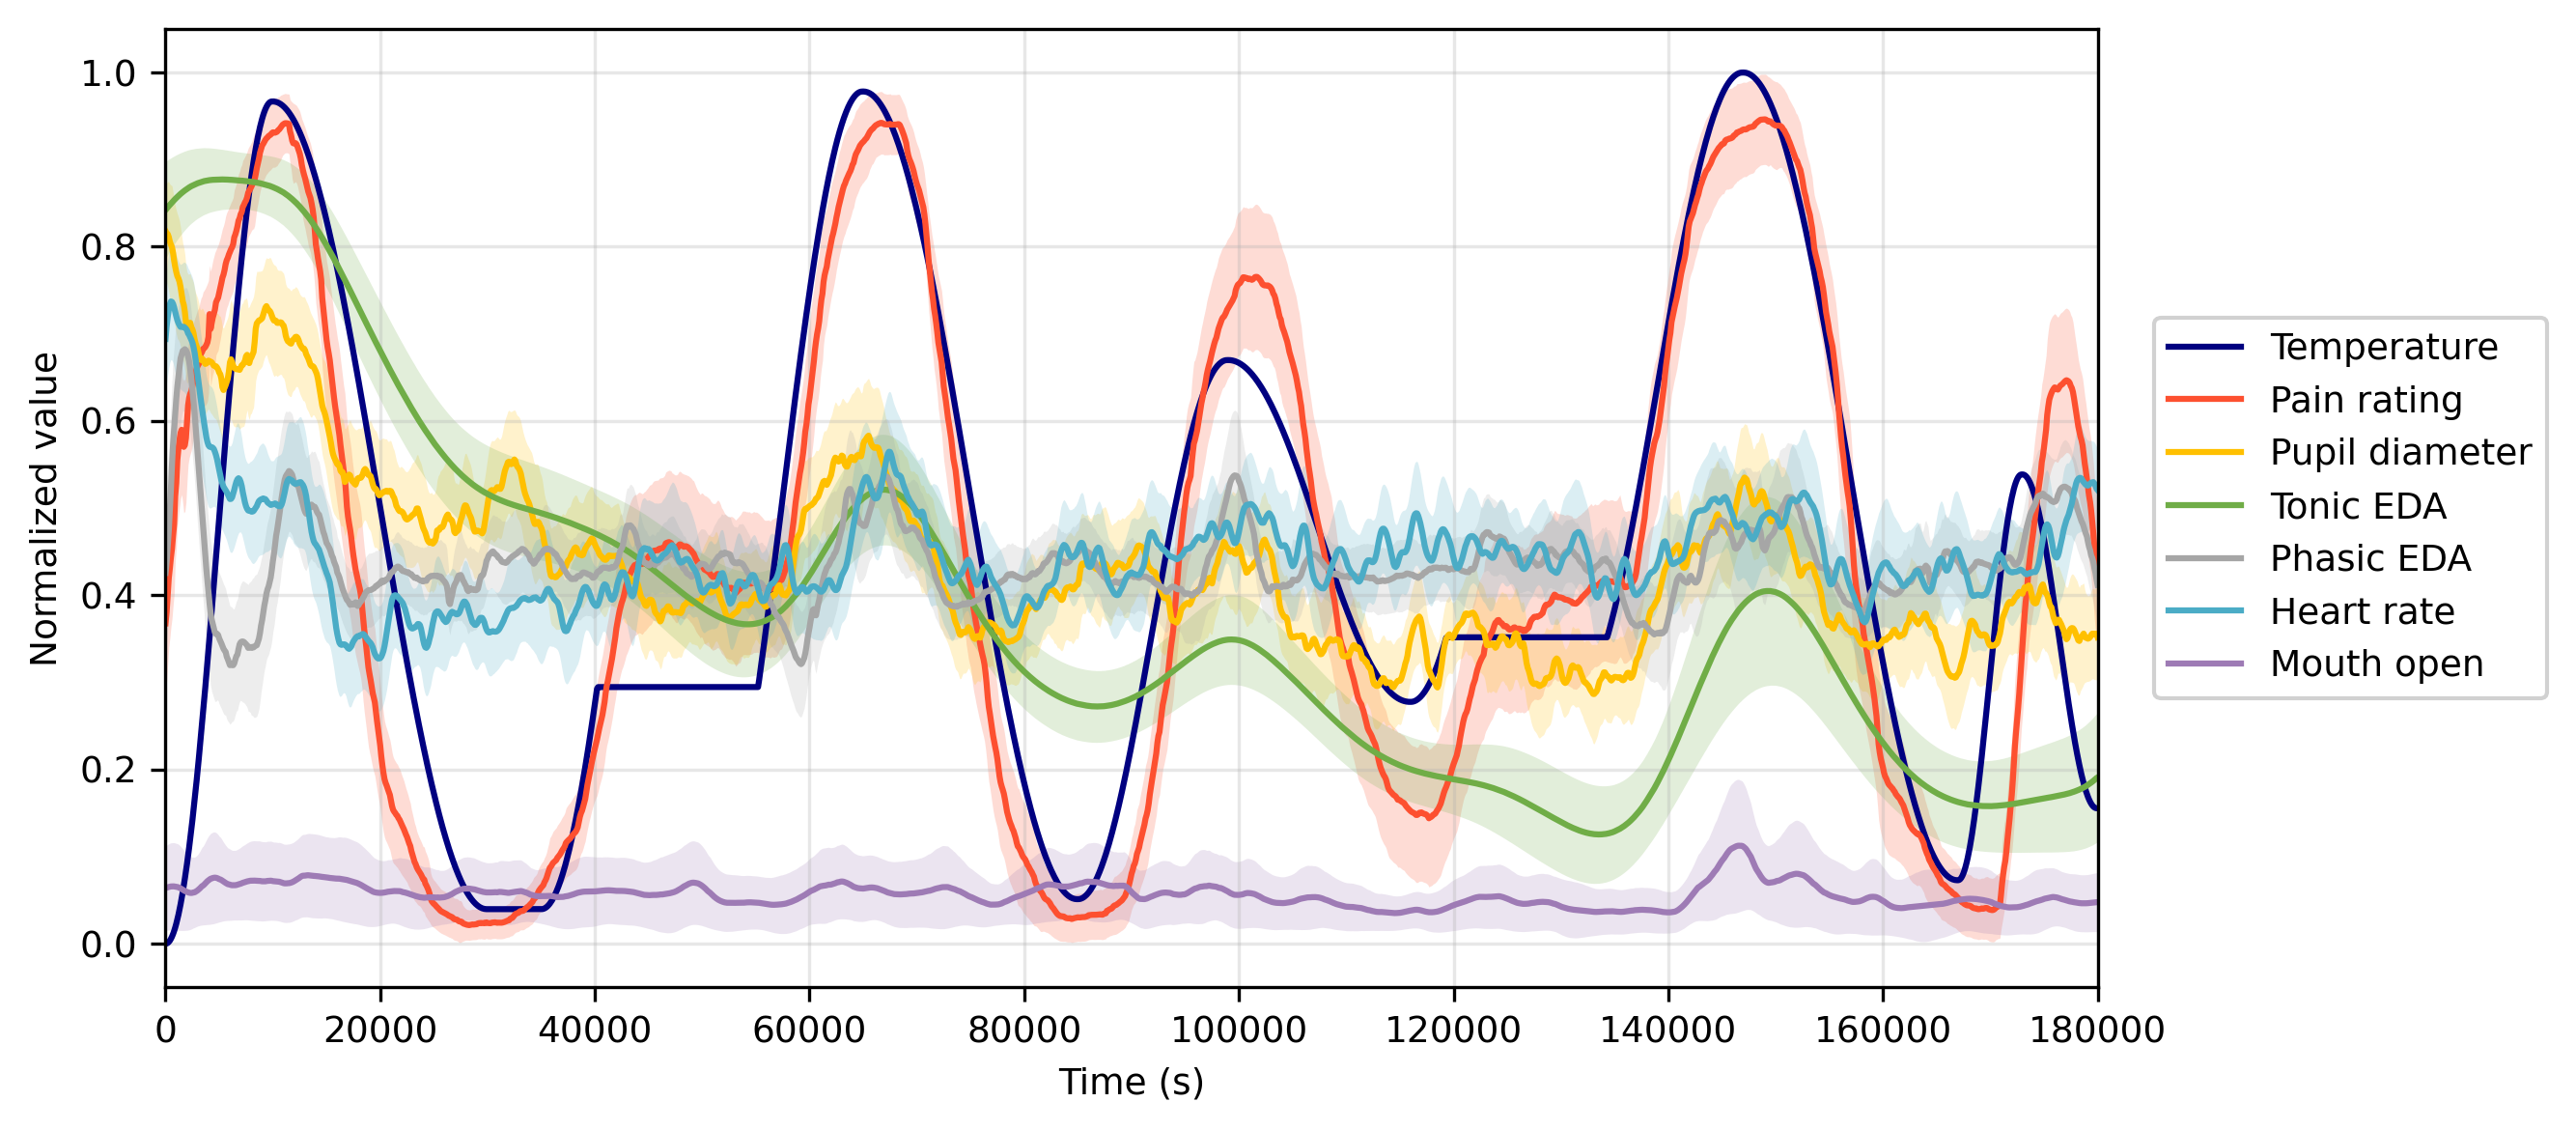

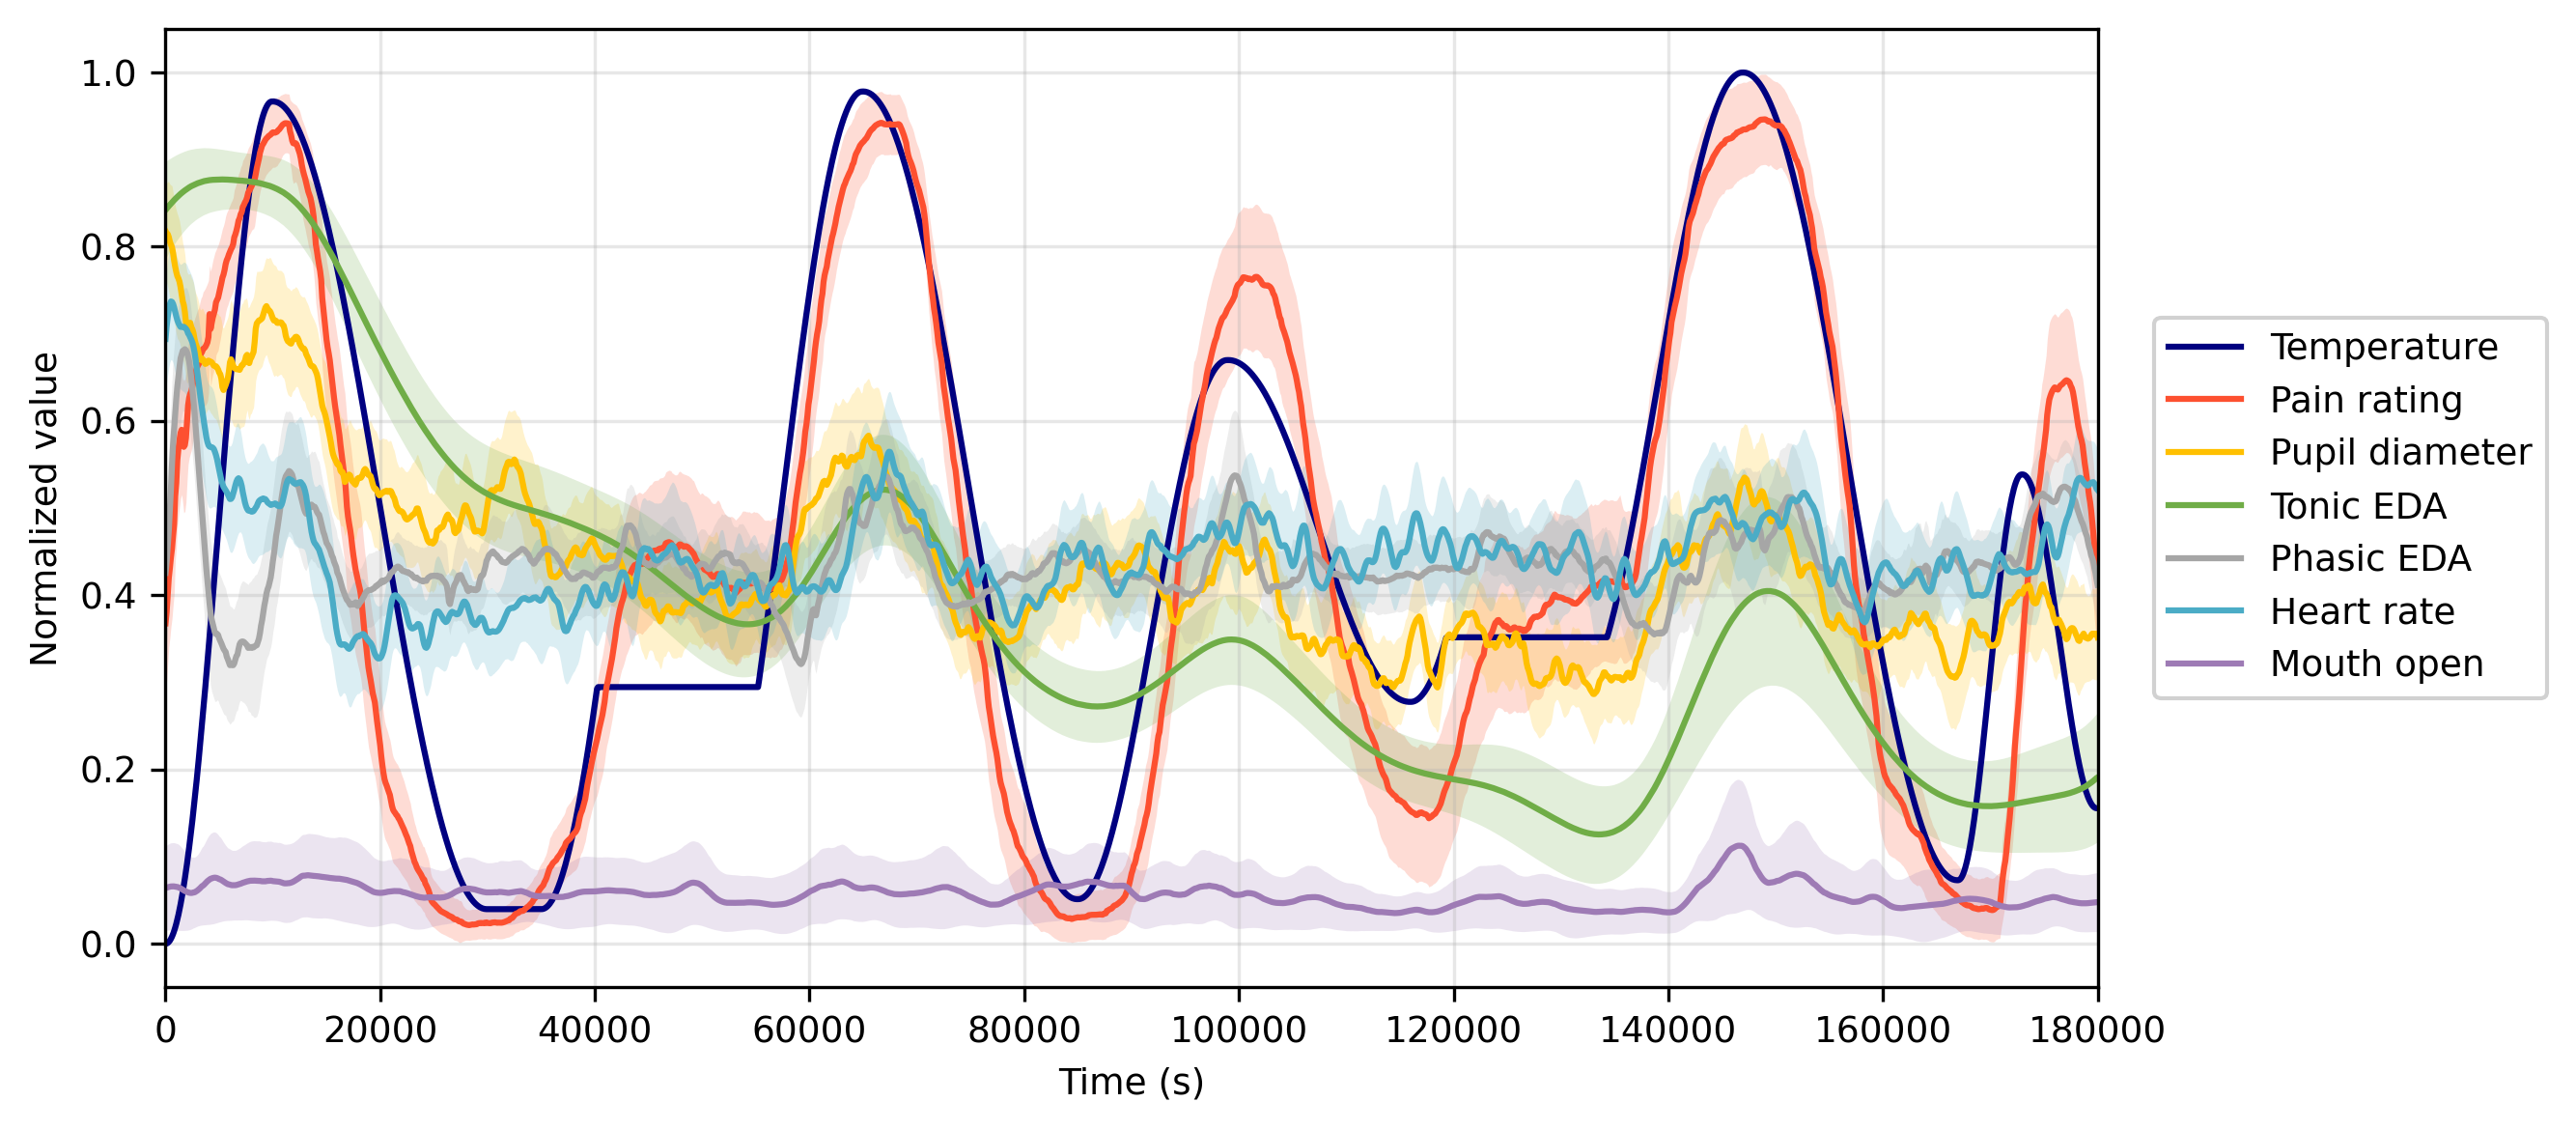

In [8]:
plot_single_stimulus_seed(averages, 133, signals)


In [10]:
import os
from pathlib import Path

import holoviews as hv
import hvplot.polars  # noqa
import polars as pl
import tomllib
from dotenv import load_dotenv

from src.experiments.measurement.stimulus_generator import StimulusGenerator
from src.features.utils import to_describe
from src.log_config import configure_logging
from src.plots.plot_stimulus import (
    plot_stimulus,
    plot_stimulus_labels,
    plot_stimulus_matplotlib,
    plot_stimulus_with_labels,
)

load_dotenv()
FIGURE_DIR = Path(os.getenv("FIGURE_DIR"))


pl.Config.set_tbl_rows(12)  # for the 12 trials
hv.output(widget_location="bottom", size=130)

In [11]:
def load_configuration(file_path: str) -> dict:
    """Load configuration from a TOML file."""
    file_path = Path(file_path)
    with open(file_path, "rb") as file:
        return tomllib.load(file)


config = load_configuration("src/experiments/measurement/measurement_config.toml")[
    "stimulus"
]


In [12]:
config = {
    "seeds": config["seeds"],
    "sample_rate": config["sample_rate"],
    "half_cycle_num": config["half_cycle_num"],
    "period_range": config["period_range"],
    "amplitude_range": config["amplitude_range"],
    "inflection_point_range": config["inflection_point_range"],
    "shorten_expected_duration": config["shorten_expected_duration"],
    "major_decreasing_half_cycle_num": config["major_decreasing_half_cycle_num"],
    "major_decreasing_half_cycle_period": config["major_decreasing_half_cycle_period"],
    "major_decreasing_half_cycle_amplitude": config[
        "major_decreasing_half_cycle_amplitude"
    ],
    "major_decreasing_half_cycle_min_y_intercept": config[
        "major_decreasing_half_cycle_min_y_intercept"
    ],
    "plateau_num": config["plateau_num"],
    "plateau_duration": config["plateau_duration"],
    "plateau_percentile_range": config["plateau_percentile_range"],
    "prolonged_minima_num": config["prolonged_minima_num"],
    "prolonged_minima_duration": config["prolonged_minima_duration"],
}
assert len(config["seeds"]) == len(set(config["seeds"])), "Seeds must be unique"
assert len(config["seeds"]) == 12, "There must be 12 seeds"

dummy_participant = {
    "temperature_baseline": 47.0,
    "temperature_range": 1.5,  # VAS 0 - VAS 70
}


dummy_config = {
    "seeds": [1, 2, 3],
    "half_cycle_num": 2,
    "period_range": [2, 2],
    "major_decreasing_half_cycle_num": 0,
    "shorten_expected_duration": 0,
    "amplitude_range": [0.9, 1.0],
    "plateau_num": 0,
    "prolonged_minima_num": 0,
}

# Plot one random seed
config.update(dummy_participant)
seed = np.random.randint(0, 1000)
stimulus = StimulusGenerator(config, debug=0, seed=467)

# print("Plot one random seed:")
plot_stimulus(stimulus, highlight_decreasing=True)

figure(id='e59c4dfc-0f66-4ad3-8807-4ec042185e9f', ...)

In [13]:
stimuli = pl.concat(
    [
        pl.DataFrame(
            {
                "y": StimulusGenerator(config, seed).y,
                "time": np.arange(len(StimulusGenerator(config, seed).y)),
                "seed": np.array([seed] * len(StimulusGenerator(config, seed).y)),
            }
        )
        for seed in config["seeds"]
    ]
)
stimuli.group_by("seed", maintain_order=True).agg(to_describe("y"))

seed,y_count,y_null_count,y_mean,y_std,y_min,y_25%,y_50%,y_75%,y_max
i64,u32,u32,f64,f64,f64,f64,f64,f64,f64
133,1800,0,46.923677,0.421417,46.25,46.665601,46.77629,47.232711,47.746504
243,1800,0,46.936088,0.417877,46.25,46.628212,46.89741,47.273344,47.738635
265,1800,0,46.933886,0.440374,46.25,46.596208,46.779867,47.291213,47.744373
396,1800,0,46.970278,0.413692,46.25,46.728107,46.936483,47.308829,47.731835
467,1800,0,46.967071,0.419495,46.25,46.685108,46.972487,47.291938,47.737302
658,1800,0,46.96046,0.41285,46.25,46.621278,46.966524,47.264738,47.704574
681,1800,0,46.932364,0.407685,46.25,46.647874,46.942859,47.242448,47.739538
743,1800,0,46.963318,0.410683,46.25,46.715073,46.884511,47.289045,47.738548
806,1800,0,46.901926,0.438545,46.25,46.566414,46.72672,47.242545,47.749272


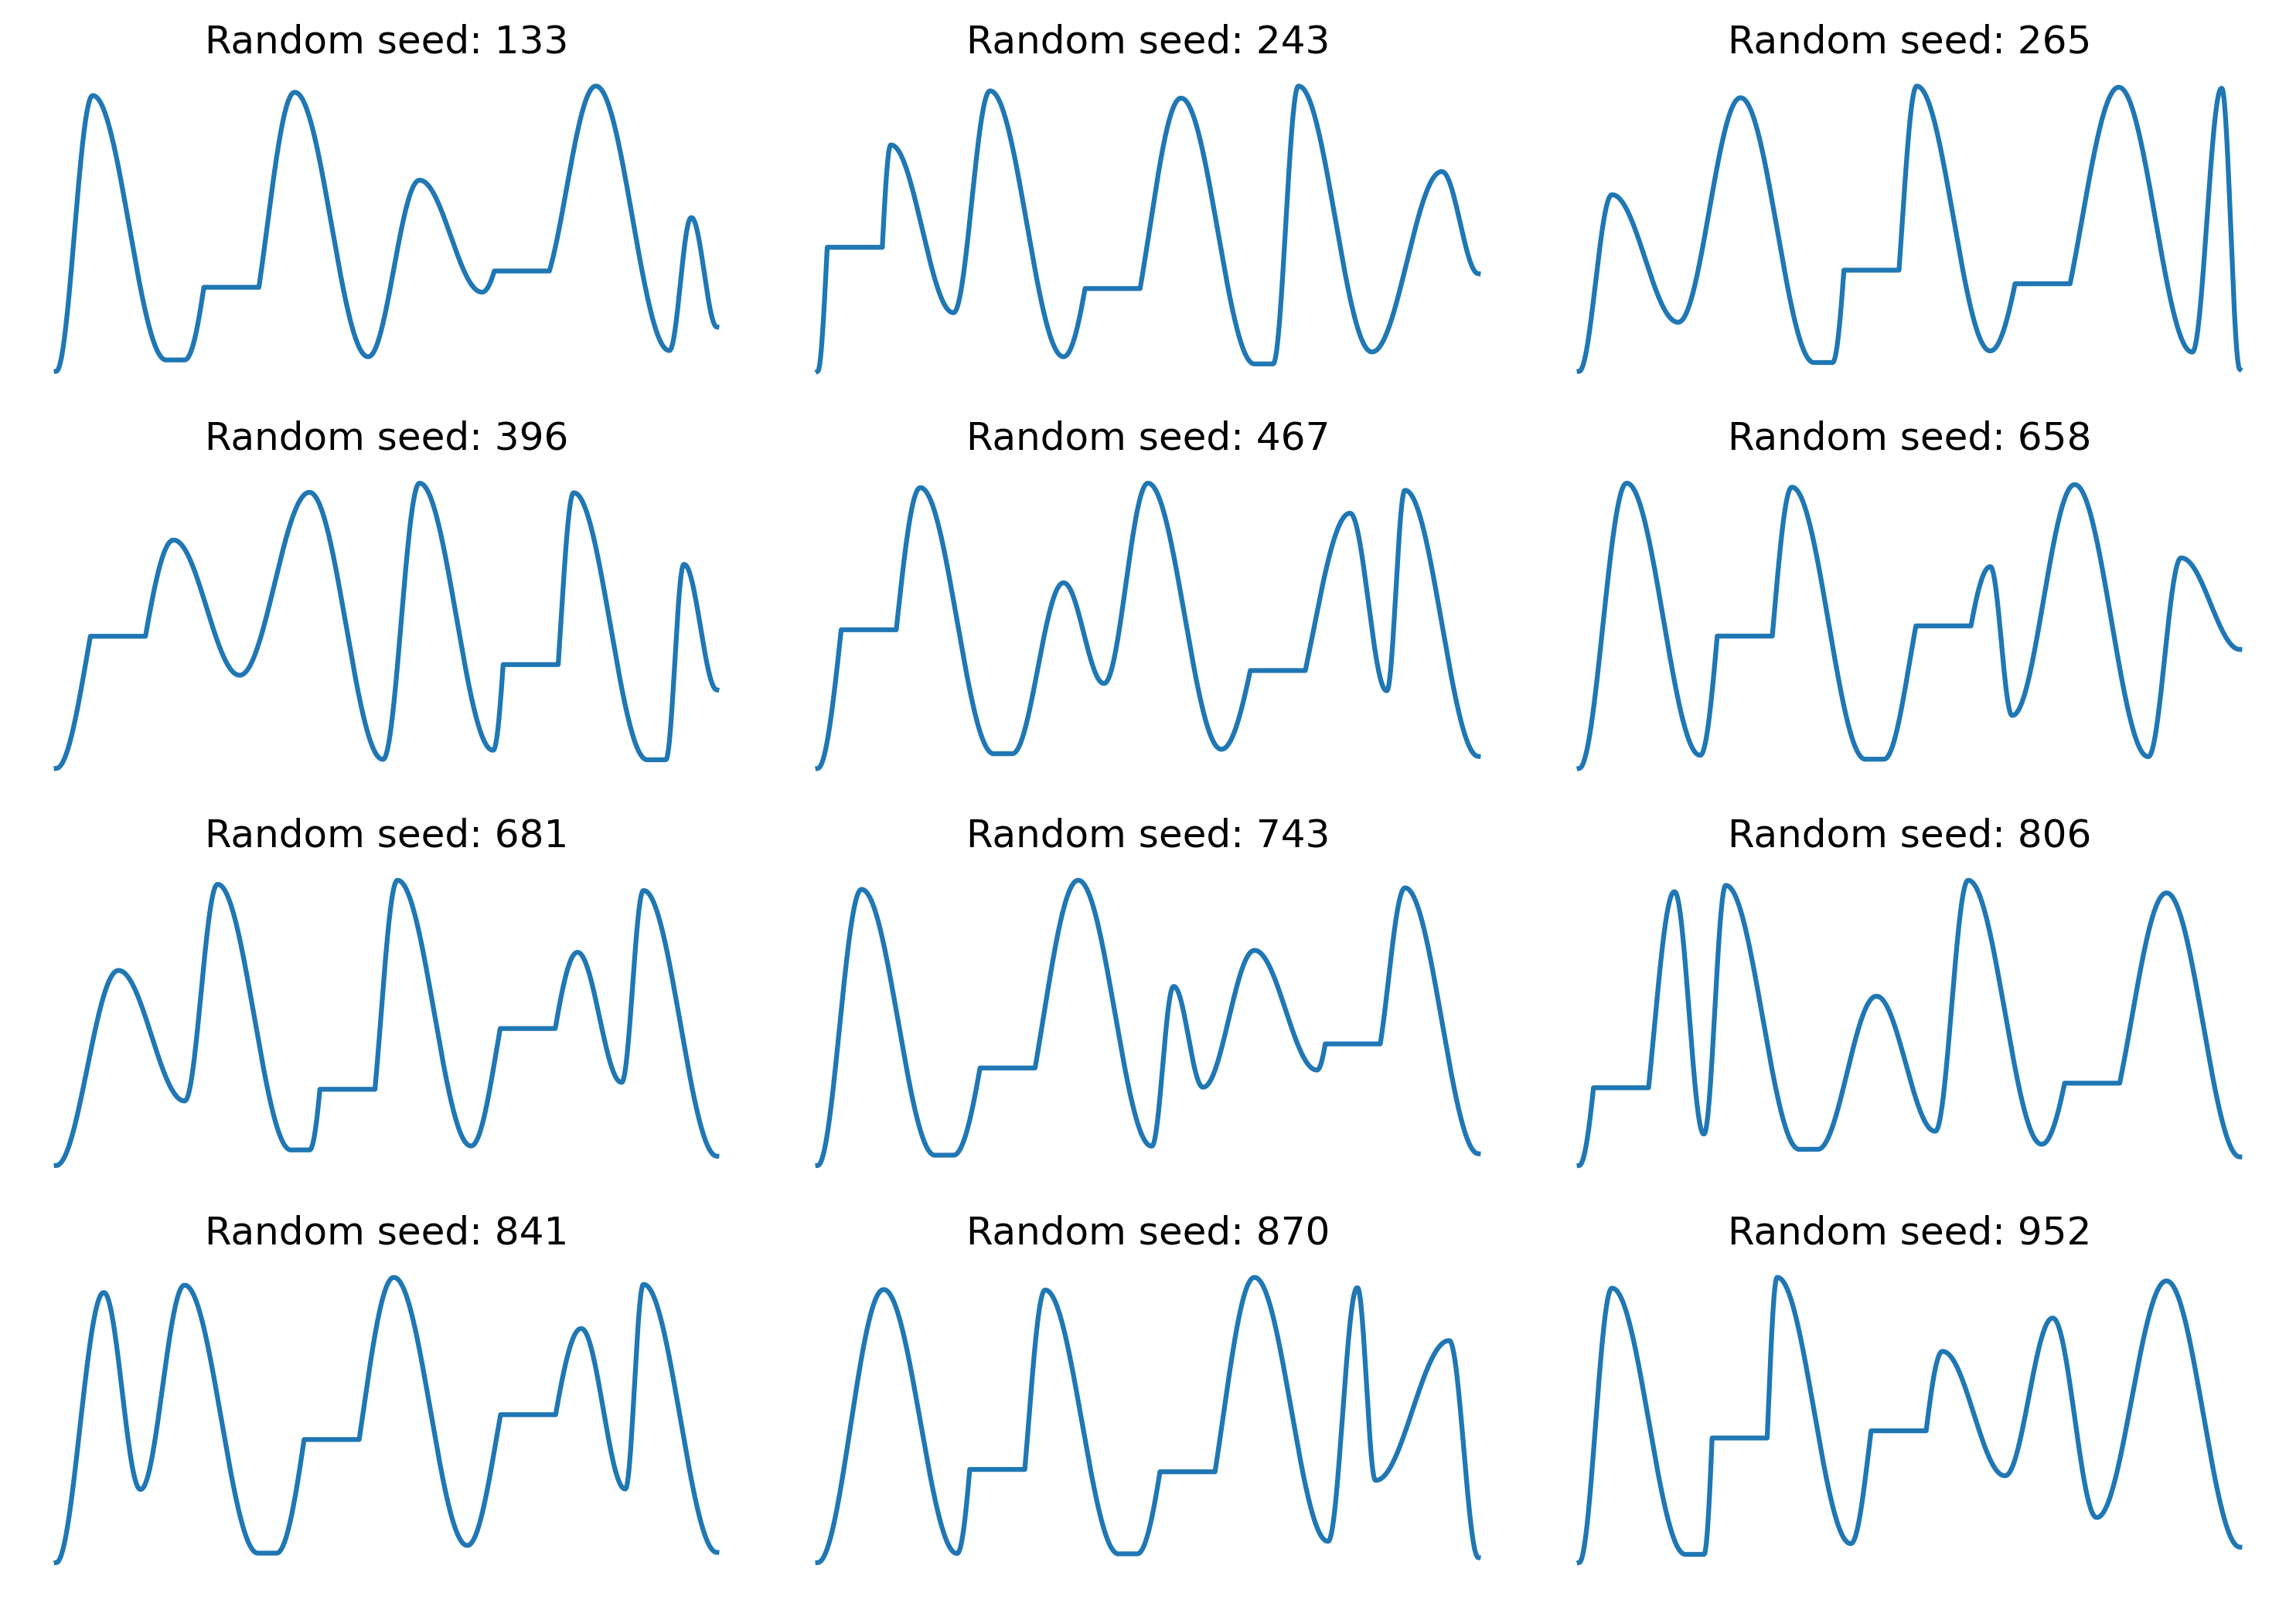

In [14]:
rows, cols = 4, 3
fig, axes = plt.subplots(rows, cols, figsize=(10, 7))
axes = axes.flatten()

grouped = stimuli.group_by("seed", maintain_order=True).agg(col("time"), col("y"))
for i, row in enumerate(grouped.to_dicts()):
    ax = axes[i]
    ax.plot(row["time"], row["y"])
    ax.set_title(f"Random seed: {row['seed']}")
    ax.axis(False)

plt.tight_layout()
plt.show()


In [15]:
# fig.savefig(FIGURE_DIR / "stimulus_seeds.png", dpi=300)